# TVSD noise-layer baseline: three I-JEPA layers plus attended noise

## Main idea

This notebook applies the architecture in `noise_layer_baseline_model_dev.ipynb` to monkey F from the **Temporal Dynamics of the Ventral Stream (TVSD)** dataset. Three mean-pooled I-JEPA feature vectors are concatenated with one independently sampled Gaussian-noise vector before the temporal attention decoder:

```text
TVSD stimulus image
    |
    +-- cached I-JEPA layers [B, 3, 1280]
    +-- Gaussian sphere noise [B, 1, 1280]
    | concatenate over attended sources
    v
Four-source tensor [B, 4, 1280]
    |
Learned time queries + feature-level attention
    |
Predicted standardized IT MUA [B, time, sites]
```

The noise vector is isotropic, normalized to the unit sphere, and rescaled to the mean norm of the three real feature vectors for that stimulus. It therefore competes at a comparable scale but contains no stable image information. The final heatmap displays all four sources and highlights the noise row.

## TVSD protocol

- Targets are baseline-corrected monkey-F IT MUA cached from 0–200 ms at 100 Hz.
- The default analysis retains the full 0–200 ms interval as twenty 10-ms bins.
- The official 22,248 unique-image pool is divided into fit and validation subsets with a seeded split.
- The official 100-image × 30-repetition test pool is untouched during fitting and checkpoint selection.
- Channel standardization and optional neural preprocessing are estimated from the fit subset only.
- Checkpoint selection follows validation stimulus correlation (`stim_r`), which is less sensitive than MSE to prediction shrinkage.

The ridge reference receives the same three I-JEPA vectors plus a fixed noise vector per stimulus. Its training and test noise draws are independent, so the added coordinates cannot provide stable predictive information.

In [1]:
import sys
from dataclasses import dataclass, field
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch

# Locate the repository whether Jupyter starts in the project root or scripts folder.
cwd = Path.cwd().resolve()
candidate_roots = [cwd, *cwd.parents]
PROJECT_ROOT = next(
    (path for path in candidate_roots if (path / "config.yaml").is_file()),
    None,
)
if PROJECT_ROOT is None:
    raise FileNotFoundError("Could not locate config.yaml.")
# end if the project root is unavailable

project_src_path = str((PROJECT_ROOT / "python_scripts" / "src").resolve())
while project_src_path in sys.path:
    sys.path.remove(project_src_path)
# end while the project source is already registered
sys.path.insert(0, project_src_path)

from IT_recap.tvsd_experiments import (
    build_variant_model,
    fit_ridge_map,
    load_project_paths,
    predict_test_trials,
    prepare_search_data,
    resolve_device,
    score_and_decompose,
    train_baseline_variant,
)

In [2]:
@dataclass
class Cfg:
    # Prepared TVSD caches.
    env: str | None = None
    mua_file_name: str = "f_THINGS_MUA_trials.mat"
    feature_archive_name: str = (
        "tvsd_monkeyF_ijepa_vith14_1k_224_features.npz"
    )

    # Cached neural target and fitted temporal window.
    area: str = "IT"
    target_fs: int = 100
    time_start_ms: float = 0.0
    time_end_ms: float = 200.0
    window_start_ms: float = 0.0
    window_end_ms: float = 200.0
    timebin_ms: float = 10.0

    # Optional neural preprocessing fitted on the training subset only.
    center_neural_features: bool = True
    robust_minmax_neurons: bool = False
    robust_percentile_range: tuple[float, float] = (1.0, 99.0)
    clip_robust_minmax: bool = True

    # Three cached I-JEPA feature depths.
    model_name: str = "ijepa_vith14_1k"
    model_source: str = "facebook/ijepa_vith14_1k"
    img_size: int = 224
    pooling: str = "mean"
    layer_names: list[str] = field(default_factory=lambda: [
        "encoder.layer.4.output.dense",
        "encoder.layer.17.output.dense",
        "encoder.layer.27.output.dense",
    ])
    trust_remote_code: bool = True
    attn_implementation: str = "sdpa"

    # Seeded TVSD split and loading.
    validation_fraction: float = 0.1
    random_seed: int = 0
    batch_size: int = 256
    num_workers: int = 0
    smoke_test: bool = False

    # Time-local attention decoder.
    epochs: int = 1000
    minimum_epochs: int = 15
    patience: int = 12
    learning_rate: float = 1e-3
    weight_decay: float = 1e-2
    temporal_embedding_dim: int = 256
    value_dim: int = 128
    mlp_hidden_dim: int = 32
    dropout: float = 0.5
    attention_granularity: str = "feature"
    selection_metric: str = "stim_r"

    # Explicit attended negative-control source.
    match_noise_norm: bool = True
    noise_layer_in_eval: bool = True
    attention_evaluation_repeats: int = 10

    # Test reliability and compute device.
    noise_ceiling_resamples: int = 40
    device: str = "auto"

# EOC


cfg = Cfg()
cfg

Cfg(env=None, mua_file_name='f_THINGS_MUA_trials.mat', feature_archive_name='tvsd_monkeyF_ijepa_vith14_1k_224_features.npz', area='IT', target_fs=100, time_start_ms=0.0, time_end_ms=200.0, window_start_ms=0.0, window_end_ms=200.0, timebin_ms=10.0, center_neural_features=True, robust_minmax_neurons=False, robust_percentile_range=(1.0, 99.0), clip_robust_minmax=True, model_name='ijepa_vith14_1k', model_source='facebook/ijepa_vith14_1k', img_size=224, pooling='mean', layer_names=['encoder.layer.4.output.dense', 'encoder.layer.17.output.dense', 'encoder.layer.27.output.dense'], trust_remote_code=True, attn_implementation='sdpa', validation_fraction=0.1, random_seed=0, batch_size=256, num_workers=0, smoke_test=False, epochs=1000, minimum_epochs=15, patience=12, learning_rate=0.001, weight_decay=0.01, temporal_embedding_dim=256, value_dim=128, mlp_hidden_dim=32, dropout=0.5, attention_granularity='feature', selection_metric='stim_r', match_noise_norm=True, noise_layer_in_eval=True, attention

## Load the aligned TVSD caches

`prepare_search_data` selects the requested time window, performs optional temporal re-binning, preserves the official repeated-test pool, makes the seeded fit/validation split, standardizes MUA channels from the fit subset only, and materializes matched feature/target loaders. The expected I-JEPA feature shapes are `[22248, 3, 1280]` for unique training images and `[100, 3, 1280]` for official test images.

The optional `center_neural_features` setting subtracts each fit-set `(neuron, time-bin)` mean. `robust_minmax_neurons` then scales each neuron using the configured fit-set percentiles pooled across time and samples, optionally clipping percentile outliers to `[0, 1]`. The fitted statistics are reused without refitting for validation and the official repeated-test pool.

In [3]:
paths = load_project_paths(cfg)
device = resolve_device(cfg.device)
data = prepare_search_data(cfg, paths, device)

expected_feature_shape = (len(cfg.layer_names), 1280)
actual_feature_shape = tuple(data["train_features"].shape[1:])
if actual_feature_shape != expected_feature_shape:
    raise RuntimeError(
        f"Expected cached features {expected_feature_shape}, got "
        f"{actual_feature_shape}."
    )
# end if the cached I-JEPA feature shape is unexpected

print(
    f"train features: {data['train_features'].shape} | "
    f"test features: {data['test_features'].shape} | "
    f"targets: {data['targets'].shape}"
)
print(
    "neural preprocessing: "
    f"center_features={cfg.center_neural_features}, "
    f"robust_minmax_neurons={cfg.robust_minmax_neurons}, "
    f"percentiles={cfg.robust_percentile_range}"
)

device mps | window 0-200 ms -> 20 bins of 10 ms (1 cached bins each) | 320 IT sites
fit 20,023 | validation 2,225 | test 3,000 presentations | 3 ijepa_vith14_1k feature groups
train features: (22248, 3, 1280) | test features: (100, 3, 1280) | targets: (25248, 20, 320)
neural preprocessing: center_features=True, robust_minmax_neurons=False, percentiles=(1.0, 99.0)


## Concatenated-feature ridge reference

A Gaussian sphere vector is appended to every unique stimulus before the four source vectors are flattened to 5120 predictors. Noise norms are matched to the corresponding real features. Fit and test noise are sampled independently, preventing the noise coordinates from carrying a stable mapping across splits.

In [4]:
ridge_rng = np.random.default_rng(cfg.random_seed)
ridge_train_noise = ridge_rng.standard_normal(
    (len(data["train_features"]), 1, data["shapes"]["feature_dim"])
).astype(np.float32)
ridge_test_noise = ridge_rng.standard_normal(
    (len(data["test_features"]), 1, data["shapes"]["feature_dim"])
).astype(np.float32)

# Normalize Gaussian draws to the sphere before matching real-source norms.
float32_epsilon = np.finfo(np.float32).eps
ridge_train_noise /= np.maximum(
    np.linalg.norm(ridge_train_noise, axis=-1, keepdims=True),
    float32_epsilon,
)
ridge_test_noise /= np.maximum(
    np.linalg.norm(ridge_test_noise, axis=-1, keepdims=True),
    float32_epsilon,
)
if cfg.match_noise_norm:
    ridge_train_reference_norm = np.linalg.norm(
        data["train_features"], axis=-1
    ).mean(axis=1, keepdims=True)
    ridge_test_reference_norm = np.linalg.norm(
        data["test_features"], axis=-1
    ).mean(axis=1, keepdims=True)
    ridge_train_noise *= ridge_train_reference_norm[:, :, None]
    ridge_test_noise *= ridge_test_reference_norm[:, :, None]
# end if noise norms should match the real sources

ridge_train_sources = np.concatenate(
    [data["train_features"], ridge_train_noise], axis=1
)
ridge_test_sources = np.concatenate(
    [data["test_features"], ridge_test_noise], axis=1
)
ridge_fit = fit_ridge_map(
    cfg,
    ridge_train_sources,
    ridge_test_sources,
    data["allmat"],
    data["indices"],
    data["subset_targets"]["train"],
    data["subset_targets"]["validation"],
)
print(
    f"ridge input: {ridge_train_sources.shape[1:]} | "
    f"alpha: {ridge_fit['alpha']:g} | "
    f"validation MSE: {ridge_fit['validation_mse']:.6f}"
)

ridge input: (4, 1280) | alpha: 100000 | validation MSE: 0.907592


## Build the noise-layer decoder

`NoiseLayerBaselineModel` receives cached `[B, 3, 1280]` I-JEPA activations and appends one new `[B, 1, 1280]` noise source on every forward pass. In feature-attention mode, the softmax operates jointly over `4 × 1280 = 5120` coordinates. The returned attention is later aggregated into four source masses that sum to one at each time bin.

In [5]:
from useful_stuff.image_processing.computational_models import imgANN

ann = imgANN(
    model_name=cfg.model_name,
    pkg="hf",
    img_size=cfg.img_size,
    pooling=cfg.pooling,
    dtype=torch.float32,
    attn_implementation=cfg.attn_implementation,
    repo_url=cfg.model_source,
    trust_remote_code=cfg.trust_remote_code,
)

torch.manual_seed(cfg.random_seed)
m = build_variant_model(
    "noise_layer",
    ann,
    cfg,
    data["shapes"]["n_timepoints"],
    data["shapes"]["n_neurons"],
).to(device)

# Confirm that the model really exposes three real sources plus noise.
preview_inputs, _ = next(iter(data["loaders"]["train"]))
m.eval()
with torch.no_grad():
    preview_sources = m._resolve_layer_features(
        preview_inputs[:2].to(device),
        use_precomputed_features=True,
    )
# end with no gradient tracking
expected_sources = (len(cfg.layer_names) + 1, data["shapes"]["feature_dim"])
if tuple(preview_sources.shape[1:]) != expected_sources:
    raise RuntimeError(
        f"Expected source shape {expected_sources}, got "
        f"{tuple(preview_sources.shape[1:])}."
    )
# end if the noise source was not concatenated
print(
    f"three I-JEPA layers + noise: {tuple(preview_sources.shape)} | "
    f"sources: {m.get_layer_names()}"
)
m

10:03:21 - device being used: mps
three I-JEPA layers + noise: (2, 4, 1280) | sources: ['encoder.layer.4.output.dense', 'encoder.layer.17.output.dense', 'encoder.layer.27.output.dense', '__gaussian_sphere_noise__']


NoiseLayerBaselineModel(
  (encoder_backbone): IJepaModel(
    (embeddings): IJepaEmbeddings(
      (patch_embeddings): IJepaPatchEmbeddings(
        (projection): Conv2d(3, 1280, kernel_size=(14, 14), stride=(14, 14))
      )
      (dropout): Dropout(p=0.0, inplace=False)
    )
    (encoder): IJepaEncoder(
      (layer): ModuleList(
        (0-31): 32 x IJepaLayer(
          (attention): IJepaAttention(
            (attention): IJepaSelfAttention(
              (query): Linear(in_features=1280, out_features=1280, bias=True)
              (key): Linear(in_features=1280, out_features=1280, bias=True)
              (value): Linear(in_features=1280, out_features=1280, bias=True)
            )
            (output): IJepaSelfOutput(
              (dense): Linear(in_features=1280, out_features=1280, bias=True)
              (dropout): Dropout(p=0.0, inplace=False)
            )
          )
          (intermediate): IJepaIntermediate(
            (dense): Linear(in_features=1280, out_features

## Train and select without touching the official test pool

The model minimizes aligned time-bin MSE. Every target bin owns a separate neural readout and receives only its matching prediction bin. There is no recurrence or temporal mixing. Early stopping and checkpoint restoration use the seeded validation subset; `selection_metric="stim_r"` selects image-dependent response structure rather than rewarding a shrunken prediction scale.

In [6]:
from useful_stuff.general_utils.utils import print_wise
history, best_epoch, best_validation_mse, best_validation_stim_r = (
    train_baseline_variant(
        m,
        data["loaders"],
        cfg,
        device,
        verbose=True,
    )
)
print_wise(
    f"restored epoch {best_epoch} | validation MSE {best_validation_mse:.6f} | validation stim_r {best_validation_stim_r:.4f}"
)

    epoch 001/1000 | train 0.928550 | validation MSE 0.928766 | validation stim_r -0.0004
    epoch 002/1000 | train 0.923692 | validation MSE 0.928252 | validation stim_r 0.0007
    epoch 003/1000 | train 0.923259 | validation MSE 0.928158 | validation stim_r 0.0015
    epoch 004/1000 | train 0.923107 | validation MSE 0.928120 | validation stim_r 0.0016
    epoch 005/1000 | train 0.923029 | validation MSE 0.928123 | validation stim_r 0.0015
    epoch 006/1000 | train 0.922975 | validation MSE 0.928119 | validation stim_r 0.0021
    epoch 007/1000 | train 0.922947 | validation MSE 0.928129 | validation stim_r 0.0025
    epoch 008/1000 | train 0.922924 | validation MSE 0.928113 | validation stim_r 0.0033
    epoch 009/1000 | train 0.922911 | validation MSE 0.928112 | validation stim_r 0.0041
    epoch 010/1000 | train 0.922902 | validation MSE 0.928117 | validation stim_r 0.0043
    epoch 011/1000 | train 0.922894 | validation MSE 0.928111 | validation stim_r 0.0048
    epoch 012/1000 |

## Final repeated-test evaluation

The selected checkpoint is now evaluated on the 100 official test images. Each image has 30 neural repetitions. The decoder receives the same image representation on those presentations but samples a fresh noise vector because `noise_layer_in_eval=True`. Test metrics below average neural and predicted responses over repetitions before computing stimulus correlations.

In [7]:
torch.manual_seed(cfg.random_seed + 1)
test_predictions, test_targets, _ = predict_test_trials(
    m, data["loaders"]["test"], device
)
model_result, model_site_correlations = score_and_decompose(
    test_predictions,
    test_targets,
    data["scoring"],
    name="I-JEPA attention + noise",
    reducer="mean",
)
ridge_result, ridge_site_correlations = score_and_decompose(
    ridge_fit["trial_predictions"],
    data["subset_targets"]["test"],
    data["scoring"],
    name="I-JEPA + noise RidgeCV",
    reducer="mean",
)
print("noise-layer decoder:", model_result)
print("ridge reference:", ridge_result)

noise-layer decoder: {'model': 'I-JEPA attention + noise', 'aggregation': 'mean', 'test_mse': 0.07775, 'variance_explained_vs_mean': 0.1598, 'mean_stim_r_response': 0.2568, 'median_stim_r_response': 0.2665, 'fraction_of_ceiling': 0.446, 'target_reliability': 0.5753, 'irreducible_mse': 0.02747, 'target_variance': 0.09023, 'predictable_variance': 0.06277, 'mse_above_floor': 0.05028, 'mean_optimal_scale': 0.7271, 'mse_after_rescaling': 0.07432}
ridge reference: {'model': 'I-JEPA + noise RidgeCV', 'aggregation': 'mean', 'test_mse': 0.07129, 'variance_explained_vs_mean': 0.2297, 'mean_stim_r_response': 0.3105, 'median_stim_r_response': 0.3479, 'fraction_of_ceiling': 0.54, 'target_reliability': 0.5753, 'irreducible_mse': 0.02747, 'target_variance': 0.09023, 'predictable_variance': 0.06277, 'mse_above_floor': 0.04382, 'mean_optimal_scale': 0.6024, 'mse_after_rescaling': 0.06586}


## Training curves and final noise-inclusive attention heatmap

Attention is averaged over every official test presentation and several independent evaluation passes. In feature mode, equal source widths mean that summing feature weights within each source is exactly its attention mass. The noise source is retained as the fourth heatmap row, highlighted in red, and repeated as a separate time course against the uniform-attention reference of `1/4`.

mean noise attention by time bin: [0.2472 0.2502 0.253  0.2561 0.2555 0.2464 0.2458 0.2494 0.2498 0.2496
 0.2495 0.2496 0.2496 0.2491 0.2481 0.2482 0.2482 0.2484 0.2475 0.2483]
overall mean noise attention: 0.2495


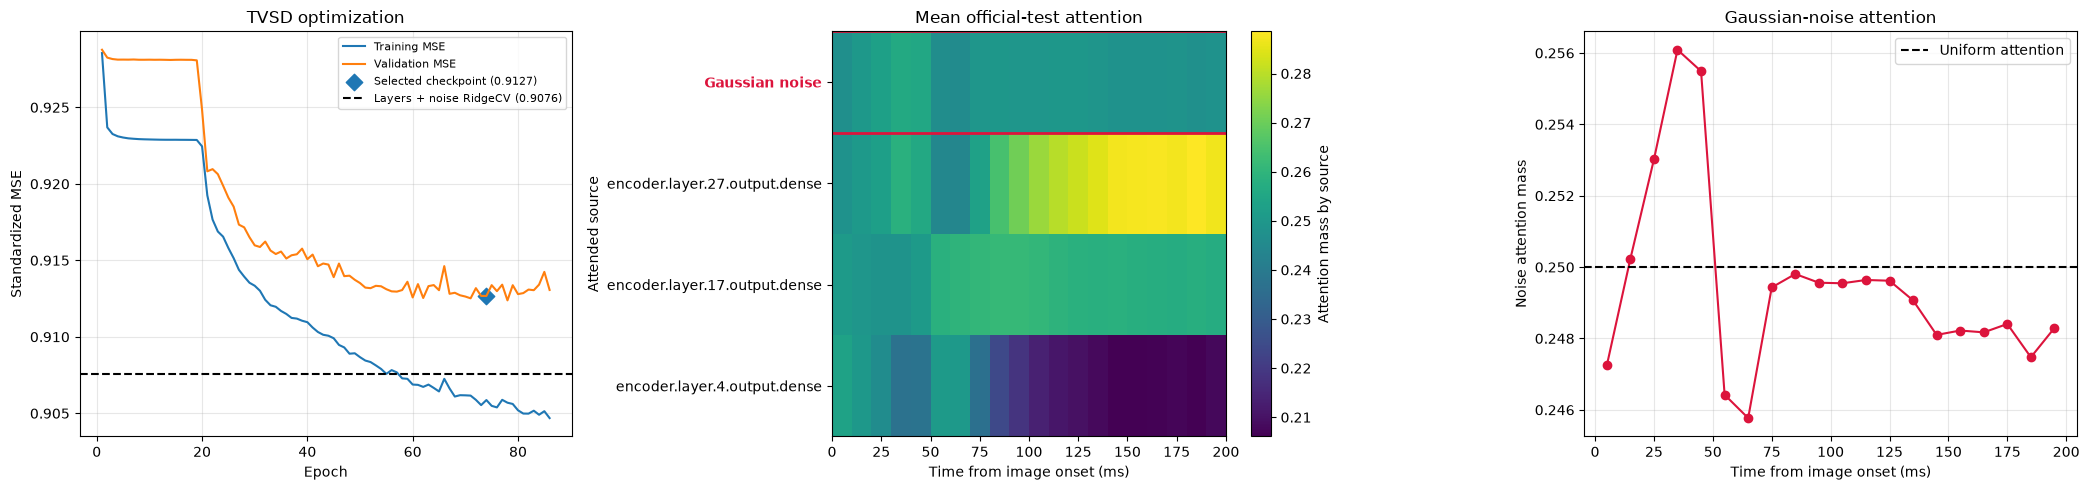

: 

In [ ]:
if cfg.attention_evaluation_repeats <= 0:
    raise ValueError("attention_evaluation_repeats must be positive.")
# end if no attention repeats were requested

torch.manual_seed(cfg.random_seed + 2)
test_attention_draws = []
for _ in range(cfg.attention_evaluation_repeats):
    _, _, current_attention = predict_test_trials(
        m, data["loaders"]["test"], device
    )
    test_attention_draws.append(current_attention)
# end for independent evaluation draw
mean_test_attention = np.mean(test_attention_draws, axis=0)

source_labels = [*cfg.layer_names, "Gaussian noise"]
if mean_test_attention.shape[1] != len(source_labels):
    raise RuntimeError("Attention sources do not match plot labels.")
# end if attention and labels are inconsistent
bin_centers_ms = (
    data["bin_edges_ms"][:-1] + data["bin_edges_ms"][1:]
) / 2.0
noise_attention = mean_test_attention[:, -1]
print(
    "mean noise attention by time bin: "
    + np.array2string(noise_attention, precision=4)
)
print(f"overall mean noise attention: {noise_attention.mean():.4f}")

history_epochs = np.asarray([row["epoch"] for row in history])
training_mse = np.asarray([row["train_mse"] for row in history])
validation_mse = np.asarray([row["validation_mse"] for row in history])

fig, axes = plt.subplots(1, 3, figsize=(21, 5))
axes[0].plot(history_epochs, training_mse, label="Training MSE")
axes[0].plot(history_epochs, validation_mse, label="Validation MSE")
axes[0].scatter(
    best_epoch,
    best_validation_mse,
    marker="D",
    s=70,
    label=f"Selected checkpoint ({best_validation_mse:.4f})",
)
axes[0].axhline(
    ridge_fit["validation_mse"],
    color="black",
    linestyle="--",
    label=f"Layers + noise RidgeCV ({ridge_fit['validation_mse']:.4f})",
)
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Standardized MSE")
axes[0].set_title("TVSD optimization")
axes[0].grid(alpha=0.3)
axes[0].legend(fontsize=8)

attention_image = axes[1].imshow(
    mean_test_attention.T,
    aspect="auto",
    origin="lower",
    interpolation="nearest",
    extent=(
        data["bin_edges_ms"][0],
        data["bin_edges_ms"][-1],
        -0.5,
        len(source_labels) - 0.5,
    ),
    cmap="viridis",
)
axes[1].set_xlabel("Time from image onset (ms)")
axes[1].set_ylabel("Attended source")
axes[1].set_title("Mean official-test attention")
axes[1].set_yticks(np.arange(len(source_labels)))
axes[1].set_yticklabels(source_labels)
noise_tick = axes[1].get_yticklabels()[-1]
noise_tick.set_color("crimson")
noise_tick.set_fontweight("bold")
noise_source_index = len(source_labels) - 1
axes[1].axhline(noise_source_index - 0.5, color="crimson", linewidth=2)
axes[1].axhline(noise_source_index + 0.5, color="crimson", linewidth=2)
fig.colorbar(
    attention_image, ax=axes[1], label="Attention mass by source"
)

axes[2].plot(
    bin_centers_ms, noise_attention, color="crimson", marker="o"
)
axes[2].axhline(
    1.0 / len(source_labels),
    color="black",
    linestyle="--",
    label="Uniform attention",
)
axes[2].set_xlabel("Time from image onset (ms)")
axes[2].set_ylabel("Noise attention mass")
axes[2].set_title("Gaussian-noise attention")
axes[2].grid(alpha=0.3)
axes[2].legend()

fig.tight_layout()
plt.show()